# Demo: Extending the Cosmology Framework

This notebook demonstrates how to use the new **generalized framework** to implement a completely new cosmological model and run a full MCMC analysis.

**Note:** We use `%autoreload` to ensure that any changes to the `src` files are reflected here immediately.

In [11]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from src.base_model import CosmologyModel
from src.run_inference import run_mcmc
from src.plotting import plot_cosmo_corner

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Define the New Model

We simply inherit from `CosmologyModel` and implement the `H(z)` function. 

For this demo, we'll use a model where $H(z) = H_0 \sqrt{1 + q_1 z + q_2 z^2}$.

In [12]:
class CustomQuadraticModel(CosmologyModel):
    def __init__(self):
        super().__init__(
            name="Custom Quadratic Expansion",
            param_names=[r"H_0", r"q_1", r"q_2"],
            param_bounds=[(40, 100), (-10.0, 10.0), (-10.0, 10.0)]
        )

    def H(self, z, H0, q1, q2):
        # H(z) = H0 * sqrt(1 + q1*z + q2*z^2)
        # Safeguard: Ensure the term under sqrt is positive
        val = 1 + q1*z + q2*z**2
        return np.where(val > 0, H0 * np.sqrt(val), np.nan)

In [16]:
# Paths to your data files
cc_data = "Cosmic_chronometers_data.tex"
sn_data = "Pantheon+SH0ES.dat.txt"

In [18]:
model, sampler, samples, results = run_mcmc("GCG", "Cosmic_chronometers_data.tex", "Pantheon+SH0ES.dat.txt")

--- Running MCMC for Generalized Chaplygin Gas ---
Starting 5000 steps with 40 walkers...


100%|██████████| 5000/5000 [01:00<00:00, 82.37it/s]

MCMC Finished!
H_0 = 72.8823 (-0.2981, +0.2940)
A_s = 0.6160 (-0.0347, +0.0346)
\alpha = -0.3921 (-0.1841, +0.1949)


## 2. Run the Unified Inference Pipeline

We can now inject this model directly into the `run_mcmc` function.

In [13]:


# Create an instance of our new model
my_model = CustomQuadraticModel()

try:
    # Run MCMC (using fewer steps for speed in this demo)
    model, sampler, samples, results = run_mcmc(
        model=my_model, 
        data_cc_path=cc_data, 
        data_sn_path=sn_data,
        nsteps=2000
    )
except ValueError as e:
    print(f"Caught expected error if cache was old: {e}")
    print("RESTART YOUR KERNEL if this persists.")

--- Running MCMC for Custom Quadratic Expansion ---
Starting 2000 steps with 40 walkers...


  1%|          | 14/2000 [00:00<00:14, 135.16it/s]C:\Users\diego\AppData\Local\Temp\ipykernel_7272\3399527380.py:13: RuntimeWarning: invalid value encountered in sqrt
  return np.where(val > 0, H0 * np.sqrt(val), np.nan)
100%|██████████| 2000/2000 [00:15<00:00, 129.35it/s]

MCMC Finished!
H_0 = 72.9397 (-0.3101, +0.3098)
q_1 = 1.0869 (-0.1241, +0.1257)
q_2 = 0.9976 (-0.2237, +0.2315)


## 3. Visualize Results

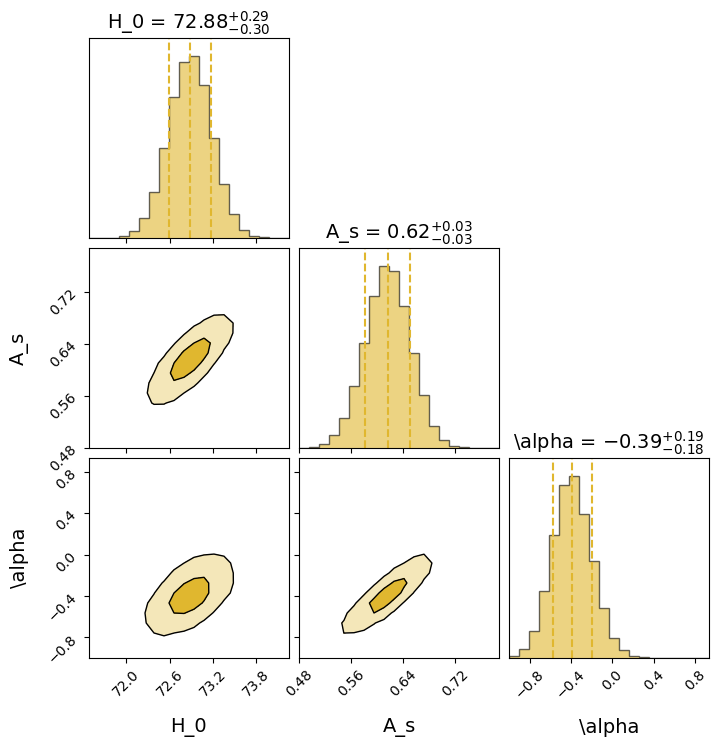

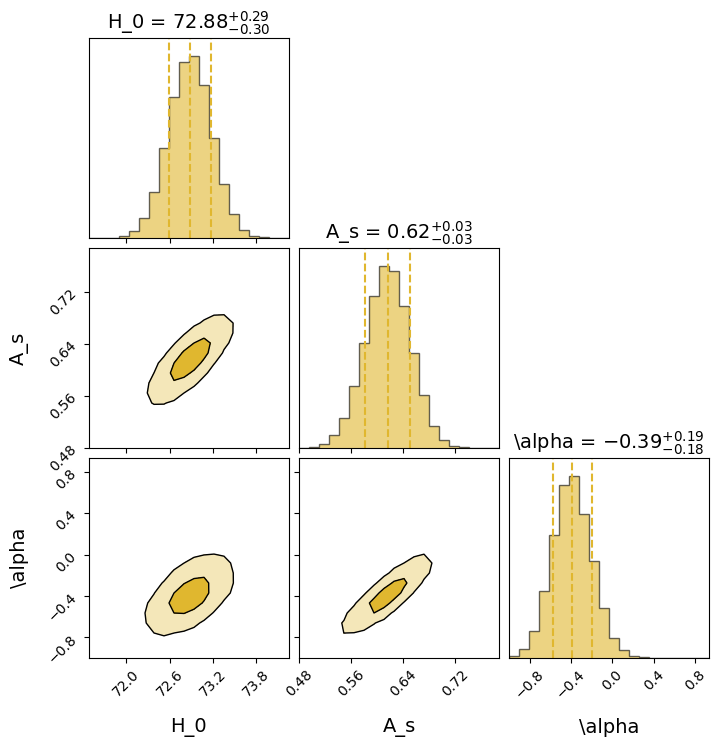

In [19]:
plot_cosmo_corner(samples, labels=model.param_names)